<a href="https://colab.research.google.com/github/abdullahnaeem151015-lgtm/ML-pipeline/blob/main/Copy_of_capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

# **Identifying Content Refresh Opportunities Using low CTR and high impressions threshold**

# **Abstract**

This study investigates whether a specific threshold for CTR and impressions can be used to identify high-potential content refresh opportunities. Using the 90th percentile of impressions among pages with at least one impression, with 100 impressions as a fallback, and the 25th percentile of positive CTR values, with 0.0001 as a fallback when needed, we establish a rule-based baseline and then evaluate supervised machine-learning models using multiple page characteristics, target-leakage checks, and a time-aware train/test split. Model performance is assessed using classification metrics, feature importance, and error analysis, with the experiments conducted on a 30% stratified sample of the dataset. Random Forest achieved the strongest ROC-AUC, Logistic Regression achieved the strongest recall, and Decision Tree slightly led several threshold-dependent metrics. The final scoring framework converted these signals into a ranked refresh queue with priority scores, reason codes, and recommended actions.

# **Inroduction / Problem Statement:**

Content pages can receive high search visibility while attracting fewer clicks than expected. In practice, this creates a prioritization problem: a large content portfolio may contain many pages with weak CTR, but reviewing every low-CTR page is neither efficient nor useful. A page with low CTR may simply have low demand, a different ranking position, a niche audience, or temporary performance changes, so low CTR alone is not enough to conclude that the page requires a refresh.

The specific challenge in this study is therefore to identify high-visibility pages whose CTR is comparatively weak and which deserve review first. The initial approach uses a transparent rule based on high impressions and low CTR: impressions above the 90th percentile of positive-impression observations and CTR below the 25th percentile of positive CTR values. This provides a practical definition of a refresh candidate, but it remains a rule-based proxy rather than confirmed evidence that every flagged page needs to be updated. My later validation also tests whether making the CTR threshold aware of ranking-position tiers changes the refresh decisions, showing that the definition of underperformance itself is an important part of the problem.

This matters because an inaccurate prioritization system can create unnecessary review work or cause genuine opportunities to be missed. A useful system should therefore help narrow a large set of observations into a manageable review queue while remaining clear that the recommendation is decision support rather than an automatic instruction to refresh. The research  itself treats the transparent baseline as something later modeling should be compared against and emphasizes reviewing the highest-ranked recommendations because that is where weak logic becomes visible.

To address this problem, this study first establishes the high-impression/low-CTR rule, then evaluates Logistic Regression, Decision Tree, and Random Forest models using additional page-performance characteristics under a time-aware validation design. The analysis also checks for target leakage, examines feature importance and prediction errors, and converts the resulting signals into a ranked action queue. The queue provides a priority score, recommended action, and reason code so that the highest-opportunity content can be reviewed first rather than treating every flagged observation equally. My queue workflow explicitly ranks content for manual review and distinguishes high-potential refresh items from broader optimization opportunities.

The remainder of the paper describes the dataset and exclusions, explains the target definition and modeling methodology, reports model and baseline results, discusses limitations, presents the ranked recommendations, and provides links to the notebooks and repository for reproducibility.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

# **Data**
This data came from **FlyRank's internship warehouse dataset**. The table used for this data is **fact_content_daily_performance_sample.parquet**. The date window  for my this ML model training and testing ranges from 1-30 June 2026 in which training time window is from 1-24 June and testing time window is from 25-30 June. The target-defining variables like gsc_impressions, gsc_clicks and CTR—were not included as model predictors because they directly contribute to constructing the refresh label and could therefore introduce target leakage. Client/content identifiers and data-availability flags (client_has_gsc, client_has_ga4, gsc_data_available, ga4_data_available) were excluded as predictors. Rows missing selected modelling features were removed before training and evaluation.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

# **Methodology**

**Assumption:**
For the assumption section of my research I assumed that the pages that recieve relatively high impressions and low CTR than than other pages in the dataset could be the reasonable candidates for the content team to review. This do not prove that page definitely requires a refresh, this just assumes that a page can be a potential candidate for a content team to investgate further.

**Features:** Features that I used for my ML models to train were:

"ga4_pageviews" "ga4_sessions","ga4_users","ga4_engaged_sessions","ga4_total_engagement_sec","sessions_organic","sessions_direct" "sessions_referral","sessions_social","sessions_paid","sessions_ai" "ai_chatgpt","ai_perplexity","ai_gemini","ai_copilot","ai_claude","ai_meta" "ai_other","scroll_events".

**Label Definition:**

According to my orignal label, I defined two thresholds, high impressions and low CTR. High impressions were calculated using 90th percentile among pages with non-zero impressions; if no valid values existed, the fallback was 100 impressions. Similarly 25th percentile was calculated among positive CTR values; if the threshold was zero or no positive CTR values existed, 0.0001 was used as the fallback. By considering these thresholds page was labelled as a refresh candidate (1) when both of these condition fulfilled.

**Validation Design:**

A time_aware_validation strategy was selected as a validation design instead of random train_test_split.The sampled observations were ordered by report date, with approximately  first 80% of unique dates used for training (June 1–24, 2026) and the remaining 20% used for testing (June 25–30, 2026). This design evaluates whether patterns learned from earlier observations can generalize to later observations, which better reflects the intended use of the refresh-candidate model. To keep the held-out test data independent, feature scaling was fitted only on the training data, while SMOTE was applied only to the training set to address class imbalance. Model performance was then evaluated on the untouched later-period test set.

**Leakage Checks**

Several leakage checks were done to to ensure that the model is not accidentally given information that directly reveals the correct answer during training including verifying that the label defining columns do not exist in the final features on which the model was trained on and maximum value of train date is less that minimum test date value to ensure that the model is trained on training dates that occurs before testing dates and train/test dates do not overlap.



## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

# **Results(vs baseline):**

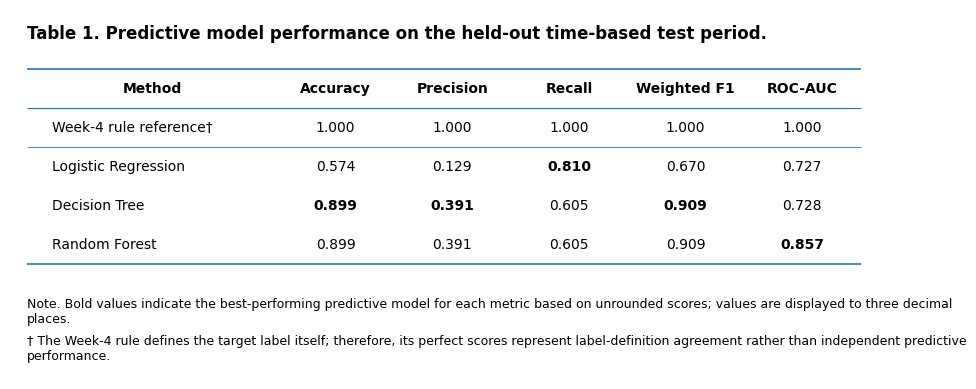

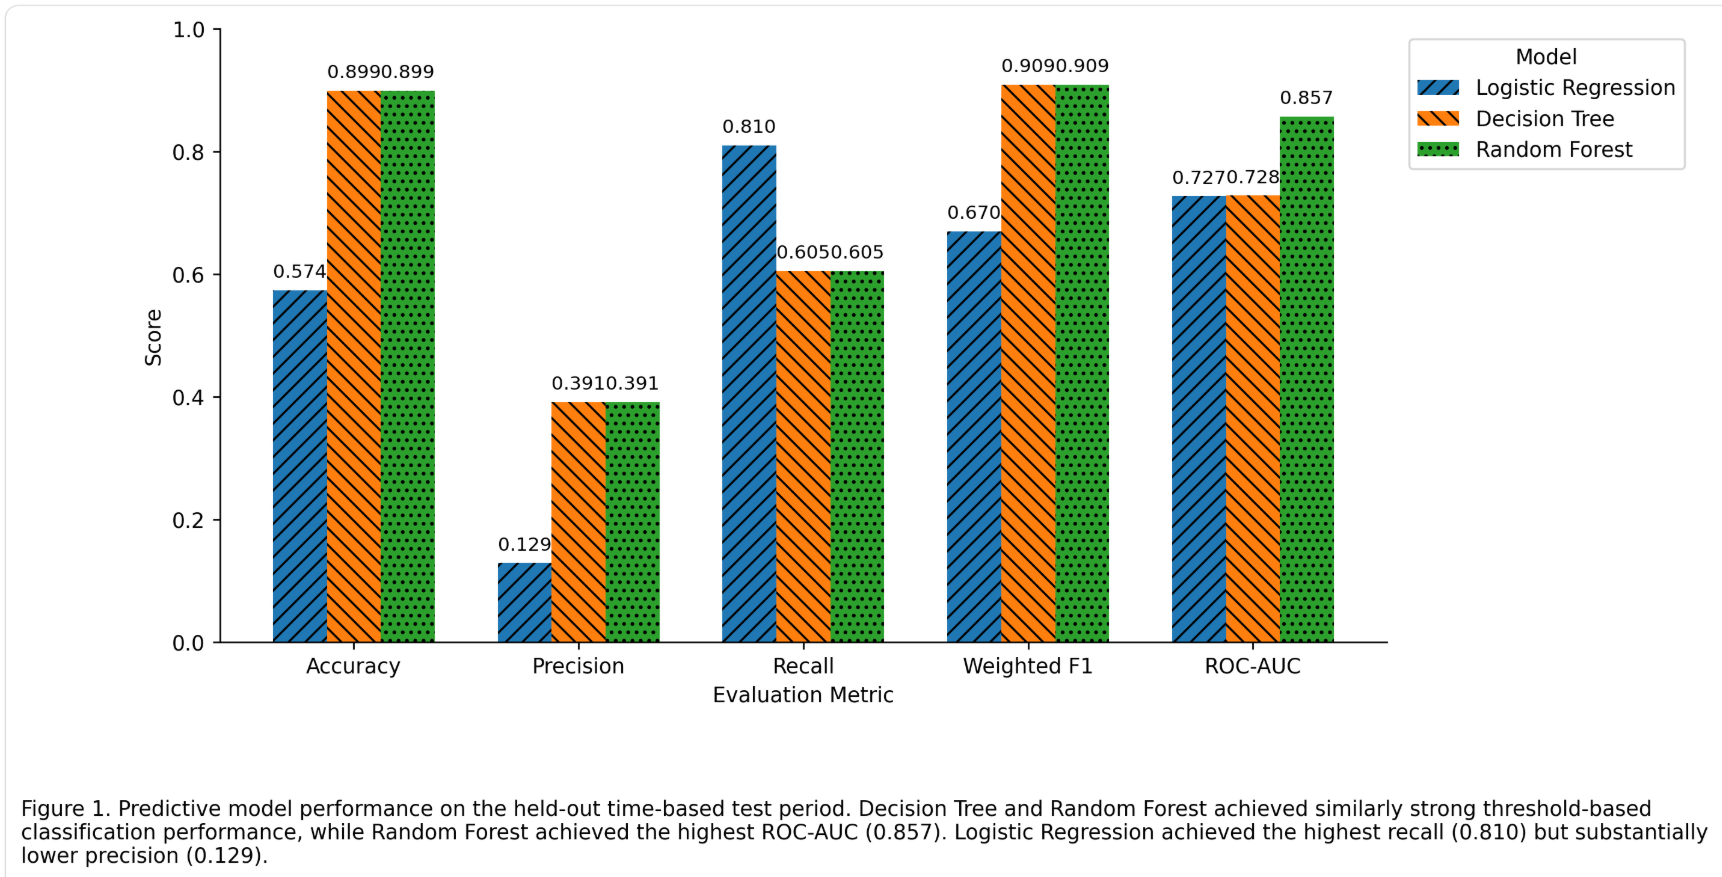

## 5. Limitations

*What this work cannot claim.*

# **Limitations:**

This reserach helps in identifying the pages that could be a potential candidate for refresh but it does not guarantee that page definitely requires a refresh.The target is constructed from percentile-based CTR and impression thresholds, so it represents a practical proxy rather than independently verified ground truth. This reserach do not claim the reason why the page requires a refresh.Rows with missing selected features are excluded before modeling, which may reduce representativeness for content with incomplete analytics data. Evaluation was conducted on a 30% stratified sample using a single time-based holdout period, so performance has not yet been demonstrated across multiple months, seasonal conditions, or future data distributions. Class imbalance also remains relevant: although SMOTE is applied to training data, precision for the refresh class remains moderate, so model outputs should be used to prioritize manual review rather than trigger automatic refresh actions. Finally, this is an observational classification system; it does not establish that refreshing a flagged page will cause CTR, traffic, or ranking improvements.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

# **Ranked recommendations:**

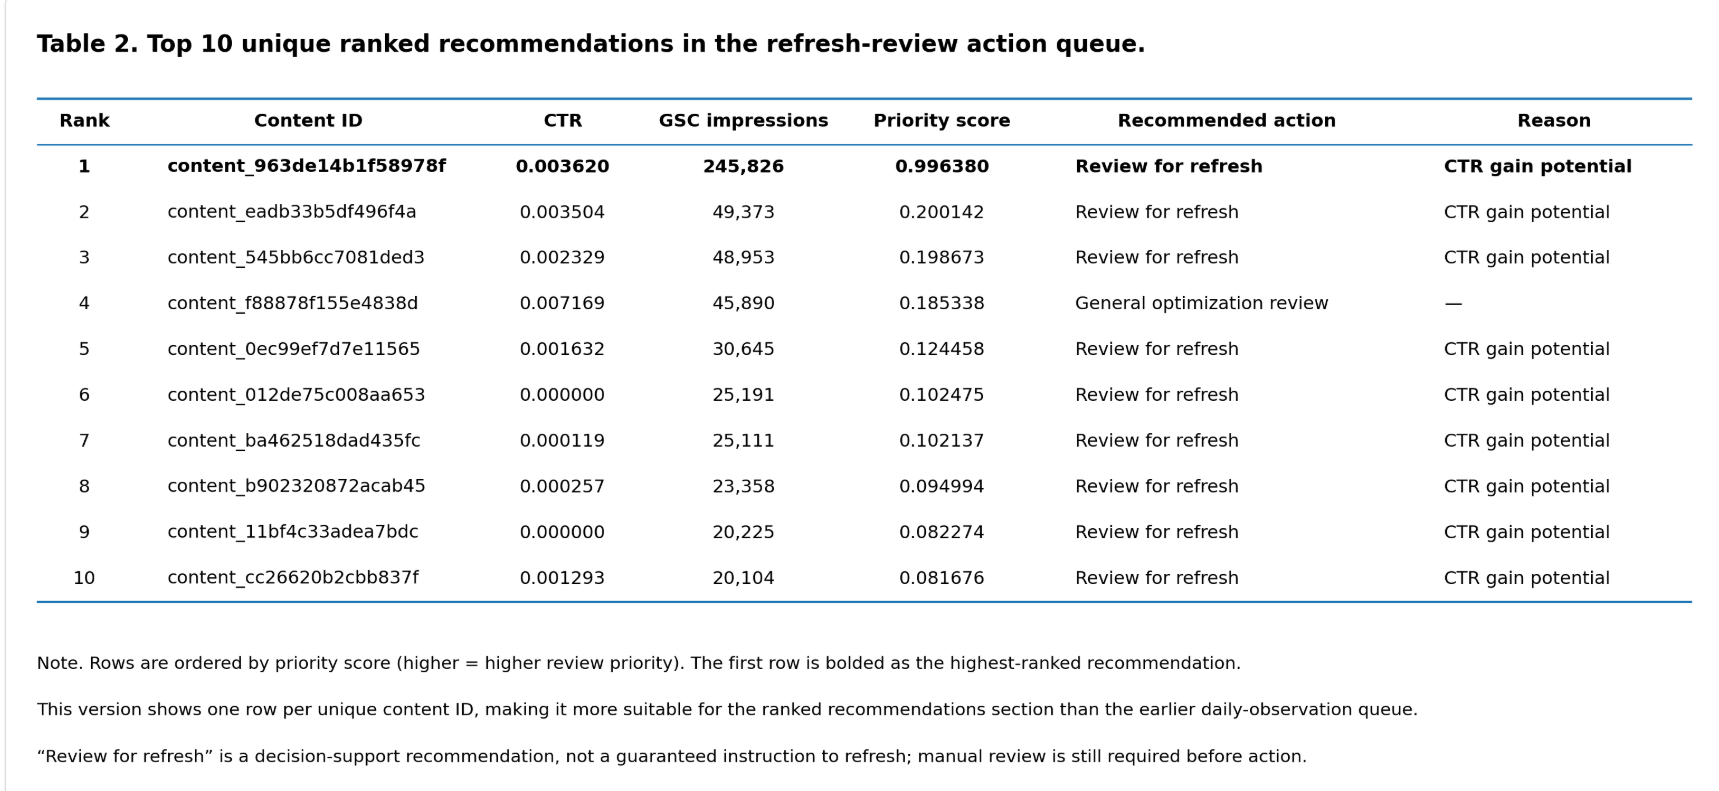

**Action playbook.** Pages appearing near the top of the queue should be reviewed first because they combine relatively high search visibility with weaker CTR performance. A high ranking does not mean that a refresh is automatically required. Each candidate should first be reviewed for possible causes such as title/meta presentation, search-intent mismatch, content freshness, ranking position, or content quality before an update is made. Lower-ranked candidates can be reviewed after the highest-opportunity pages.

# **Reproducibility**

The analysis and model-development workflow are available in the linked notebooks below. These notebooks contain the preprocessing, target construction, model training, validation, permutation importance, error analysis, ranked recommendation logic, and supporting experiments used to produce the results presented in this paper.

**Week 4 — Baseline & Refresh Rule**

Defines the refresh-candidate rule and baseline scoring logic.

[**View Notebook**](https://github.com/abdullahnaeem151015-lgtm/ML-pipeline/blob/main/work/notebooks/Copy_of_w04_baseline_score%20(1).ipynb)

**Week 5 — Model Development & Evaluation**

Logistic Regression, Decision Tree, Random Forest, time-aware validation, SMOTE, permutation importance, and error analysis.

[**View Notebook**](https://github.com/abdullahnaeem151015-lgtm/ML-pipeline/blob/main/work/notebooks/Copy_of_w05_model%20(4).ipynb)

**Week 6 — Validation & Rule Audit**
Leakage checks and comparison of the original CTR rule with the position-aware alternative.

[**View Notebook**](https://github.com/abdullahnaeem151015-lgtm/ML-pipeline/blob/main/work/notebooks/Copy_of_w06_validation_audit.ipynb)

**Week 7 — Ranked Recommendations / Action Playbook**

Priority scoring, action assignment, and generation of the ranked refresh-review queue.

[**View Notebook**](https://github.com/abdullahnaeem151015-lgtm/ML-pipeline/blob/main/work/notebooks/Copy_of_w07_action_playbook%20(1).ipynb)

**GitHub Repository**

Complete project code, notebooks, outputs, and supporting files.

[**View Repository**](https://github.com/abdullahnaeem151015-lgtm/ML-pipeline/tree/main)

# **Acknowledgements & Data Credit:**

This project was completed as part of the FlyRank ML Internship. The analysis was built on the FlyRank ML Internship dataset, including pseudonymized Google Search Console and Google Analytics performance data used for research and model development. The author acknowledges FlyRank for providing the dataset, project framework, and internship environment that supported this study.

**Data credit:** Built on the FlyRank ML Internship dataset https://flyrank.ai

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
